# Quantitative Research & Event-Driven Backtesting Challenge
## Candidate: Quant Engineer Intern Research Submission
### Firm: AlgoChowk
**Hypothesis Under Investigation:**
> *"After a significant one-day fall in NIFTY, the market tends to recover over the next few trading days."*

---
### Table of Contents
1. **Research Design & Formalization**
2. **Data Sourcing, Validation & Quality Assurance**
3. **Event Detection & Forward Return Extraction**
4. **Statistical Hypothesis Testing & Bootstrapping**
5. **Baseline Comparison & Parameter Sensitivity Grid**
6. **Out-of-Sample Validation & Regime Instability**
7. **Event-Driven Backtest Simulation (with Friction)**
8. **Challenge Your Own Result & Falsification**
9. **Conclusion & Recommendations**

## 1. Setup Environment and Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to path
sys.path.insert(0, os.path.abspath('../src'))

from data_loader import fetch_nifty_data, validate_and_clean_data
from event_engine import EventEngine
from statistical_tests import (
    analyze_horizons,
    compute_summary_statistics,
    bootstrap_confidence_interval,
    run_comparative_hypothesis_tests
)
from backtester import EventBacktester
from visualizer import (
    plot_return_distribution,
    plot_forward_returns_comparison,
    plot_sensitivity_heatmap,
    plot_equity_and_drawdowns,
    plot_regime_comparison
)

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
print('Environment initialized successfully.')

Environment initialized successfully.


## 2. Data Sourcing & Validation
We source daily NIFTY 50 (`^NSEI`) data from 2007 through 2026. Every bar is checked for:
- Missing dates and calendar gaps
- Duplicate timestamps
- Chronological sort monotonicity
- OHLC integrity: $High \ge Low$, $High \ge \max(Open, Close)$, $Low \le \min(Open, Close)$

In [2]:
df = fetch_nifty_data(cache_path='../data/nifty_50_historical.csv')
print(f"Total Clean Trading Days: {len(df)}")
print(f"Date Coverage: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
df.head()

[DataLoader] Loading cached NIFTY 50 data from '../data/nifty_50_historical.csv'...
Total Clean Trading Days: 4664
Date Coverage: 2007-09-17 to 2026-09-21


,date,open,high,low,close,volume,daily_return,log_return,intraday_return,overnight_gap
0,2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,0.0,NaN,NaN,-0.005267,NaN
1,2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,0.0,0.011469,0.011404,0.011593,-0.000122
2,2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,0.0,0.040946,0.040130,0.040020,0.000891
3,2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,0.0,0.003212,0.003207,0.002682,0.000528
4,2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,0.0,0.018957,0.018780,0.017799,0.001138


[Visualizer] Saved return distribution plot to '../reports/figures/event_distribution.png'


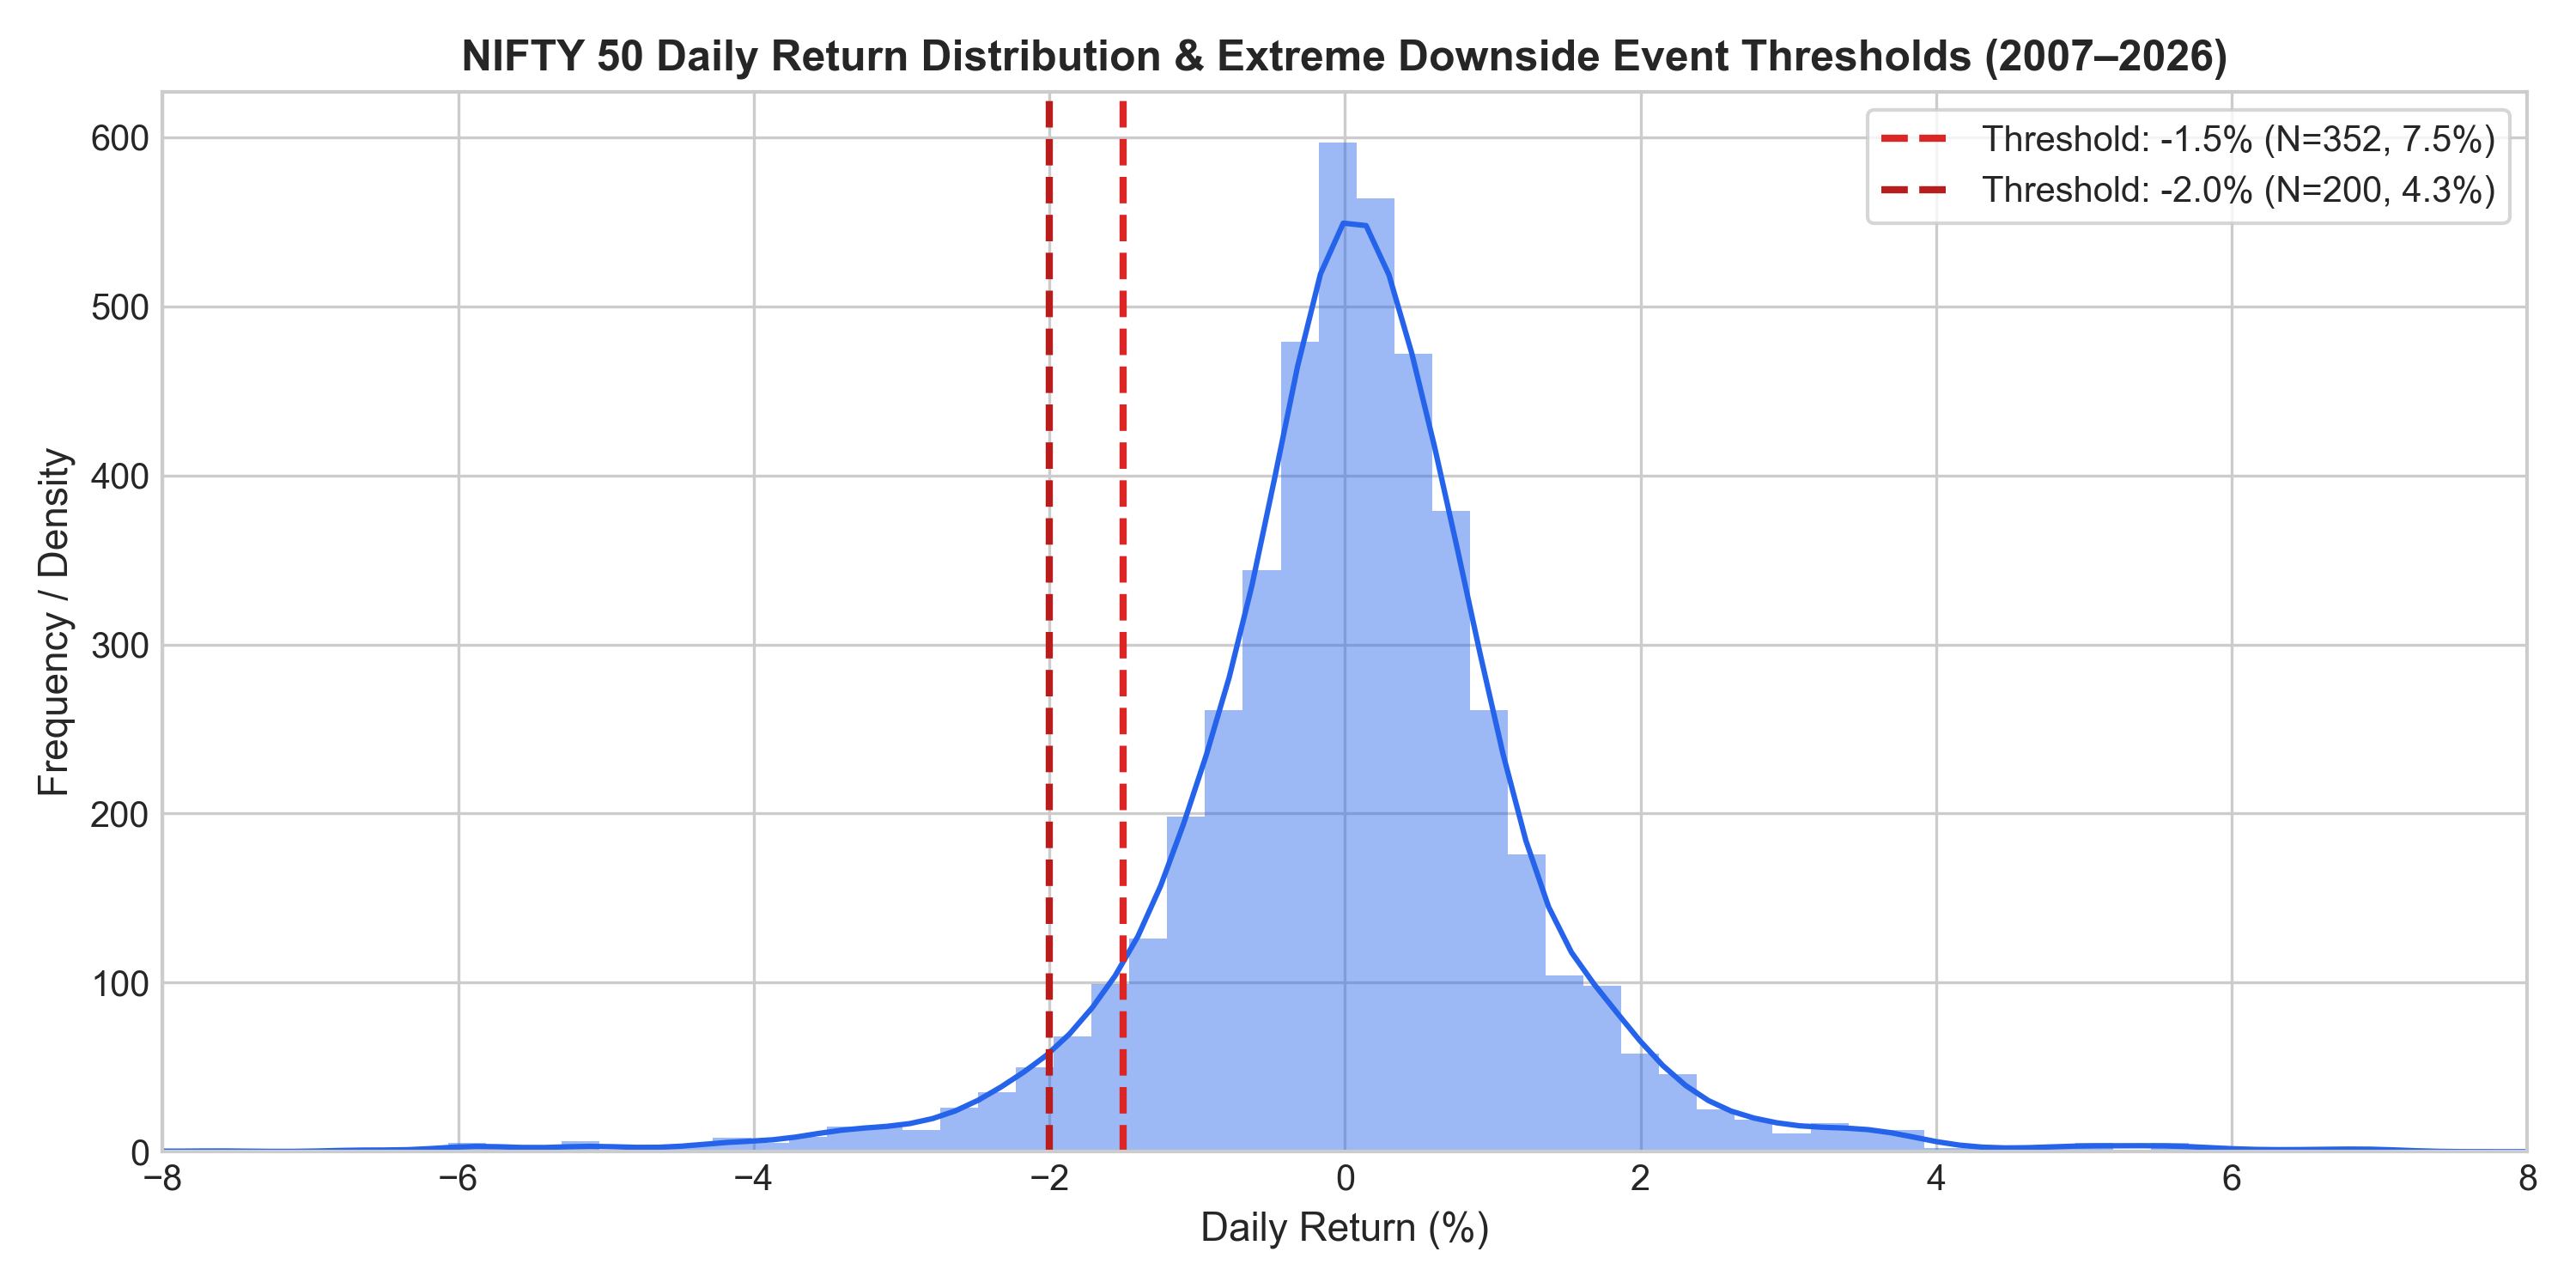

In [3]:
# Plot return distribution and event thresholds
plot_return_distribution(df, thresholds=[-0.015, -0.020], save_path='../reports/figures/event_distribution.png')

# Display inline
from IPython.display import Image
Image('../reports/figures/event_distribution.png')

## 3. Event Detection & Forward Return Extraction
We define a **significant fall** as a daily Close-to-Close drop $\le -1.5\%$.
Crucially, we evaluate two execution models:
1. **Theoretical Execution ($T$ Close Entry):** Assumes instantaneous execution at the exact moment the market closes.
2. **Realistic Execution ($T+1$ Open Entry):** Reflects live market reality where the crash is confirmed at $T$ Close, and the order executes at the next trading day's Open price.

In [4]:
engine = EventEngine(df)
full_fwd = engine.calculate_forward_returns(holding_periods=[1, 2, 3, 5, 10])
events_raw = engine.extract_event_dataset(threshold=-0.015, filter_overlapping=False)
events_indep = engine.extract_event_dataset(threshold=-0.015, filter_overlapping=True, lockout_window=3)

print(f"Total Qualifying Events (<= -1.5%): {len(events_raw)}")
print(f"Independent Events (3-day lockout window): {len(events_indep)}")
events_raw[['date', 'open', 'close', 'daily_return', 'fwd_ret_open_1d', 'fwd_ret_open_3d', 'fwd_ret_open_5d']].head(10)

Total Qualifying Events (<= -1.5%): 352
Independent Events (3-day lockout window): 244


,date,open,close,daily_return,fwd_ret_open_1d,fwd_ret_open_3d,fwd_ret_open_5d
14,2007-10-08,5186.250000,5085.100098,-0.019428,0.052265,0.091296,0.120046
18,2007-10-12,5525.299805,5428.250000,-0.017485,0.044590,0.024123,-0.039248
21,2007-10-17,5658.899902,5559.299805,-0.019186,-0.036047,-0.066131,-0.009899
22,2007-10-18,5551.100098,5351.000000,-0.037469,-0.027060,0.021146,0.038915
23,2007-10-19,5360.350098,5215.299805,-0.025360,-0.003604,0.056393,0.096016
44,2007-11-20,5911.250000,5780.899902,-0.021455,-0.037681,-0.029452,-0.013956
45,2007-11-21,5778.799805,5561.049805,-0.038030,-0.008141,0.030020,0.009506
61,2007-12-13,6159.250000,6058.100098,-0.016430,-0.001404,-0.051831,-0.047835
63,2007-12-17,6037.950195,5777.000000,-0.044761,-0.006110,-0.001921,0.050739
79,2008-01-10,6278.100098,6156.950195,-0.018343,0.005424,-0.014984,-0.041100


## 4. Statistical Hypothesis Testing & 5,000-Sample Bootstrapping
We test if event forward returns exceed the unconditional baseline (NIFTY's natural drift).
- Two-sample Welch's t-test (unequal variances)
- Mann-Whitney U test (non-parametric median difference)
- 5,000 bootstrap resamples for empirical 95% Confidence Intervals
- Bonferroni correction for multi-horizon comparisons

In [5]:
res_open = analyze_horizons(events_raw, full_fwd, holding_periods=[1, 2, 3, 5, 10], entry_mode='open')
res_close = analyze_horizons(events_raw, full_fwd, holding_periods=[1, 2, 3, 5, 10], entry_mode='close')

print('=== REALISTIC EXECUTION (T+1 Open Entry) ===')
display(res_open[['holding_days', 'event_mean', 'baseline_mean', 'diff_means', 'event_win_rate', 'welch_t_stat', 'welch_p_val', 'bonferroni_p_val']])

print('=== THEORETICAL EXECUTION (T Close Entry) ===')
display(res_close[['holding_days', 'event_mean', 'baseline_mean', 'diff_means', 'event_win_rate', 'welch_t_stat', 'welch_p_val', 'bonferroni_p_val']])

=== REALISTIC EXECUTION (T+1 Open Entry) ===


,holding_days,event_mean,baseline_mean,diff_means,event_win_rate,welch_t_stat,welch_p_val,bonferroni_p_val
0,1,-0.000208,0.000437,-0.000645,0.494318,-0.577982,0.563626,1.0
1,2,-0.000016,0.000879,-0.000894,0.508523,-0.551543,0.581593,1.0
2,3,0.001992,0.001309,0.000683,0.553977,0.360301,0.718826,1.0
3,5,0.003026,0.002150,0.000876,0.545455,0.344803,0.730437,1.0
4,10,0.004781,0.004230,0.000551,0.565341,0.163294,0.870375,1.0


=== THEORETICAL EXECUTION (T Close Entry) ===


,holding_days,event_mean,baseline_mean,diff_means,event_win_rate,welch_t_stat,welch_p_val,bonferroni_p_val
0,1,0.000535,0.000437,0.000098,0.542614,0.084764,0.932495,1.0
1,2,0.000761,0.000879,-0.000118,0.505682,-0.069022,0.945009,1.0
2,3,0.002809,0.001309,0.001500,0.545455,0.738319,0.460788,1.0
3,5,0.003837,0.002150,0.001687,0.548295,0.640600,0.522179,1.0
4,10,0.005600,0.004230,0.001371,0.571023,0.397436,0.691273,1.0


[Visualizer] Saved forward returns comparison plot to '../reports/figures/forward_returns_comparison.png'


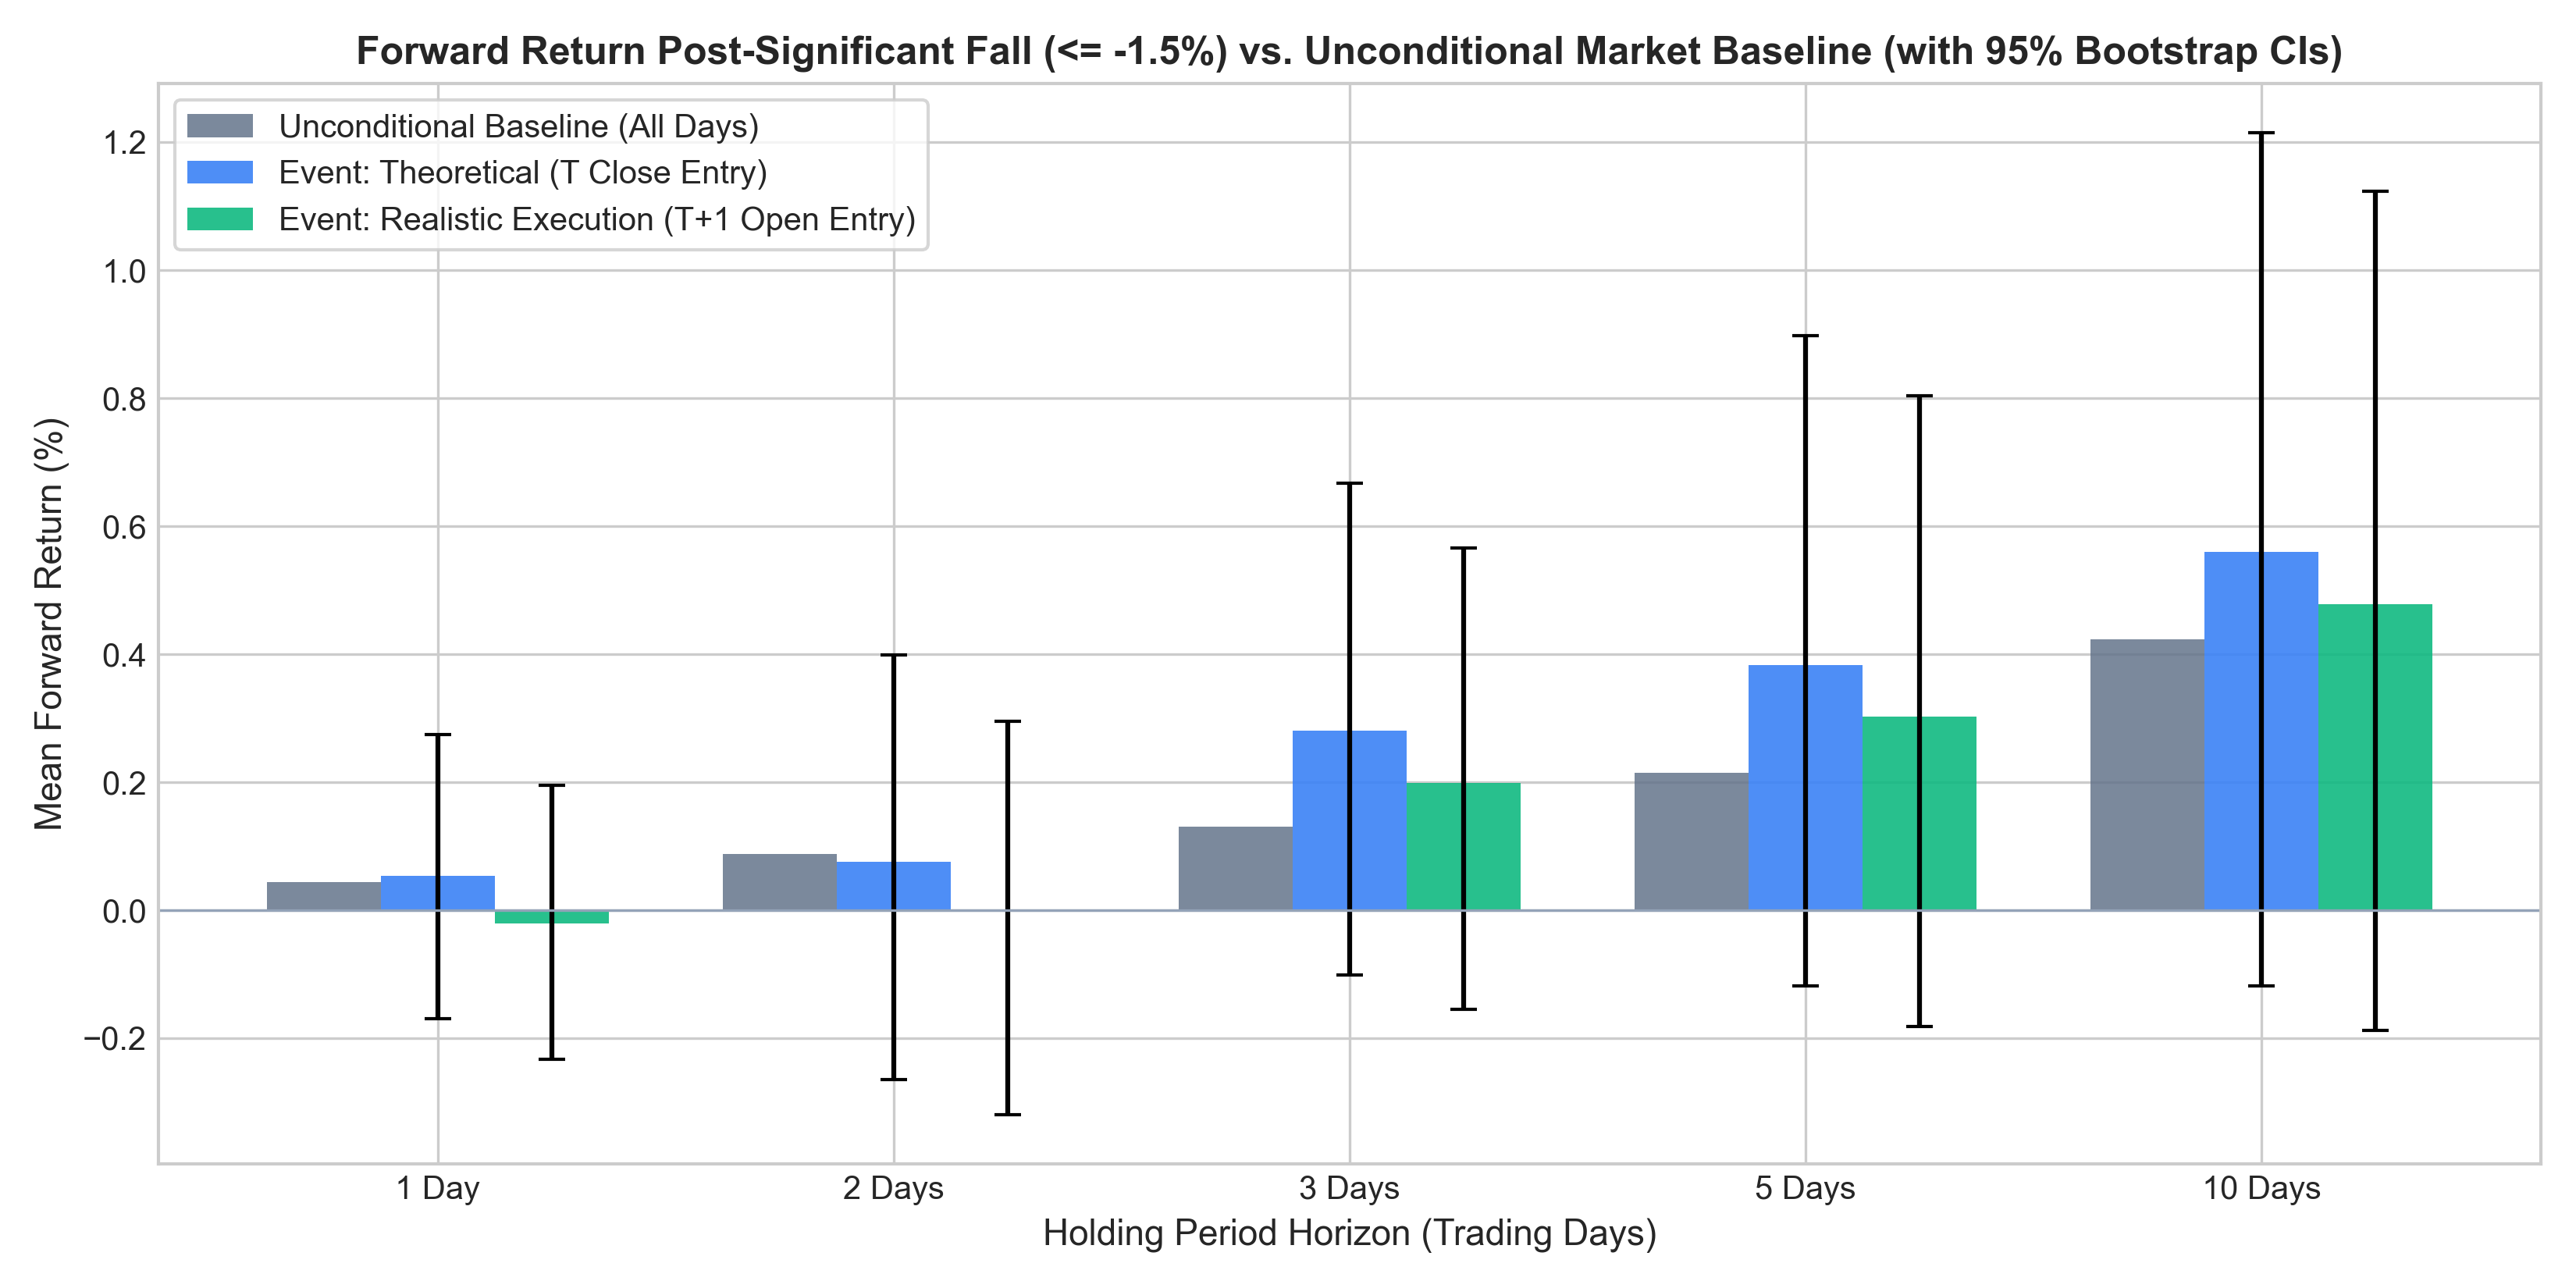

In [6]:
plot_forward_returns_comparison(res_open, res_close, save_path='../reports/figures/forward_returns_comparison.png')
Image('../reports/figures/forward_returns_comparison.png')

## 5. Robustness & Parameter Sensitivity Heatmap
We stress-test across a 2D grid of thresholds ($-1.0\%$ to $-3.0\%$) and holding horizons ($1$ to $10$ days) to rule out curve-fitting and data snooping.

[Visualizer] Saved sensitivity heatmap to '../reports/figures/parameter_sensitivity_heatmap.png'


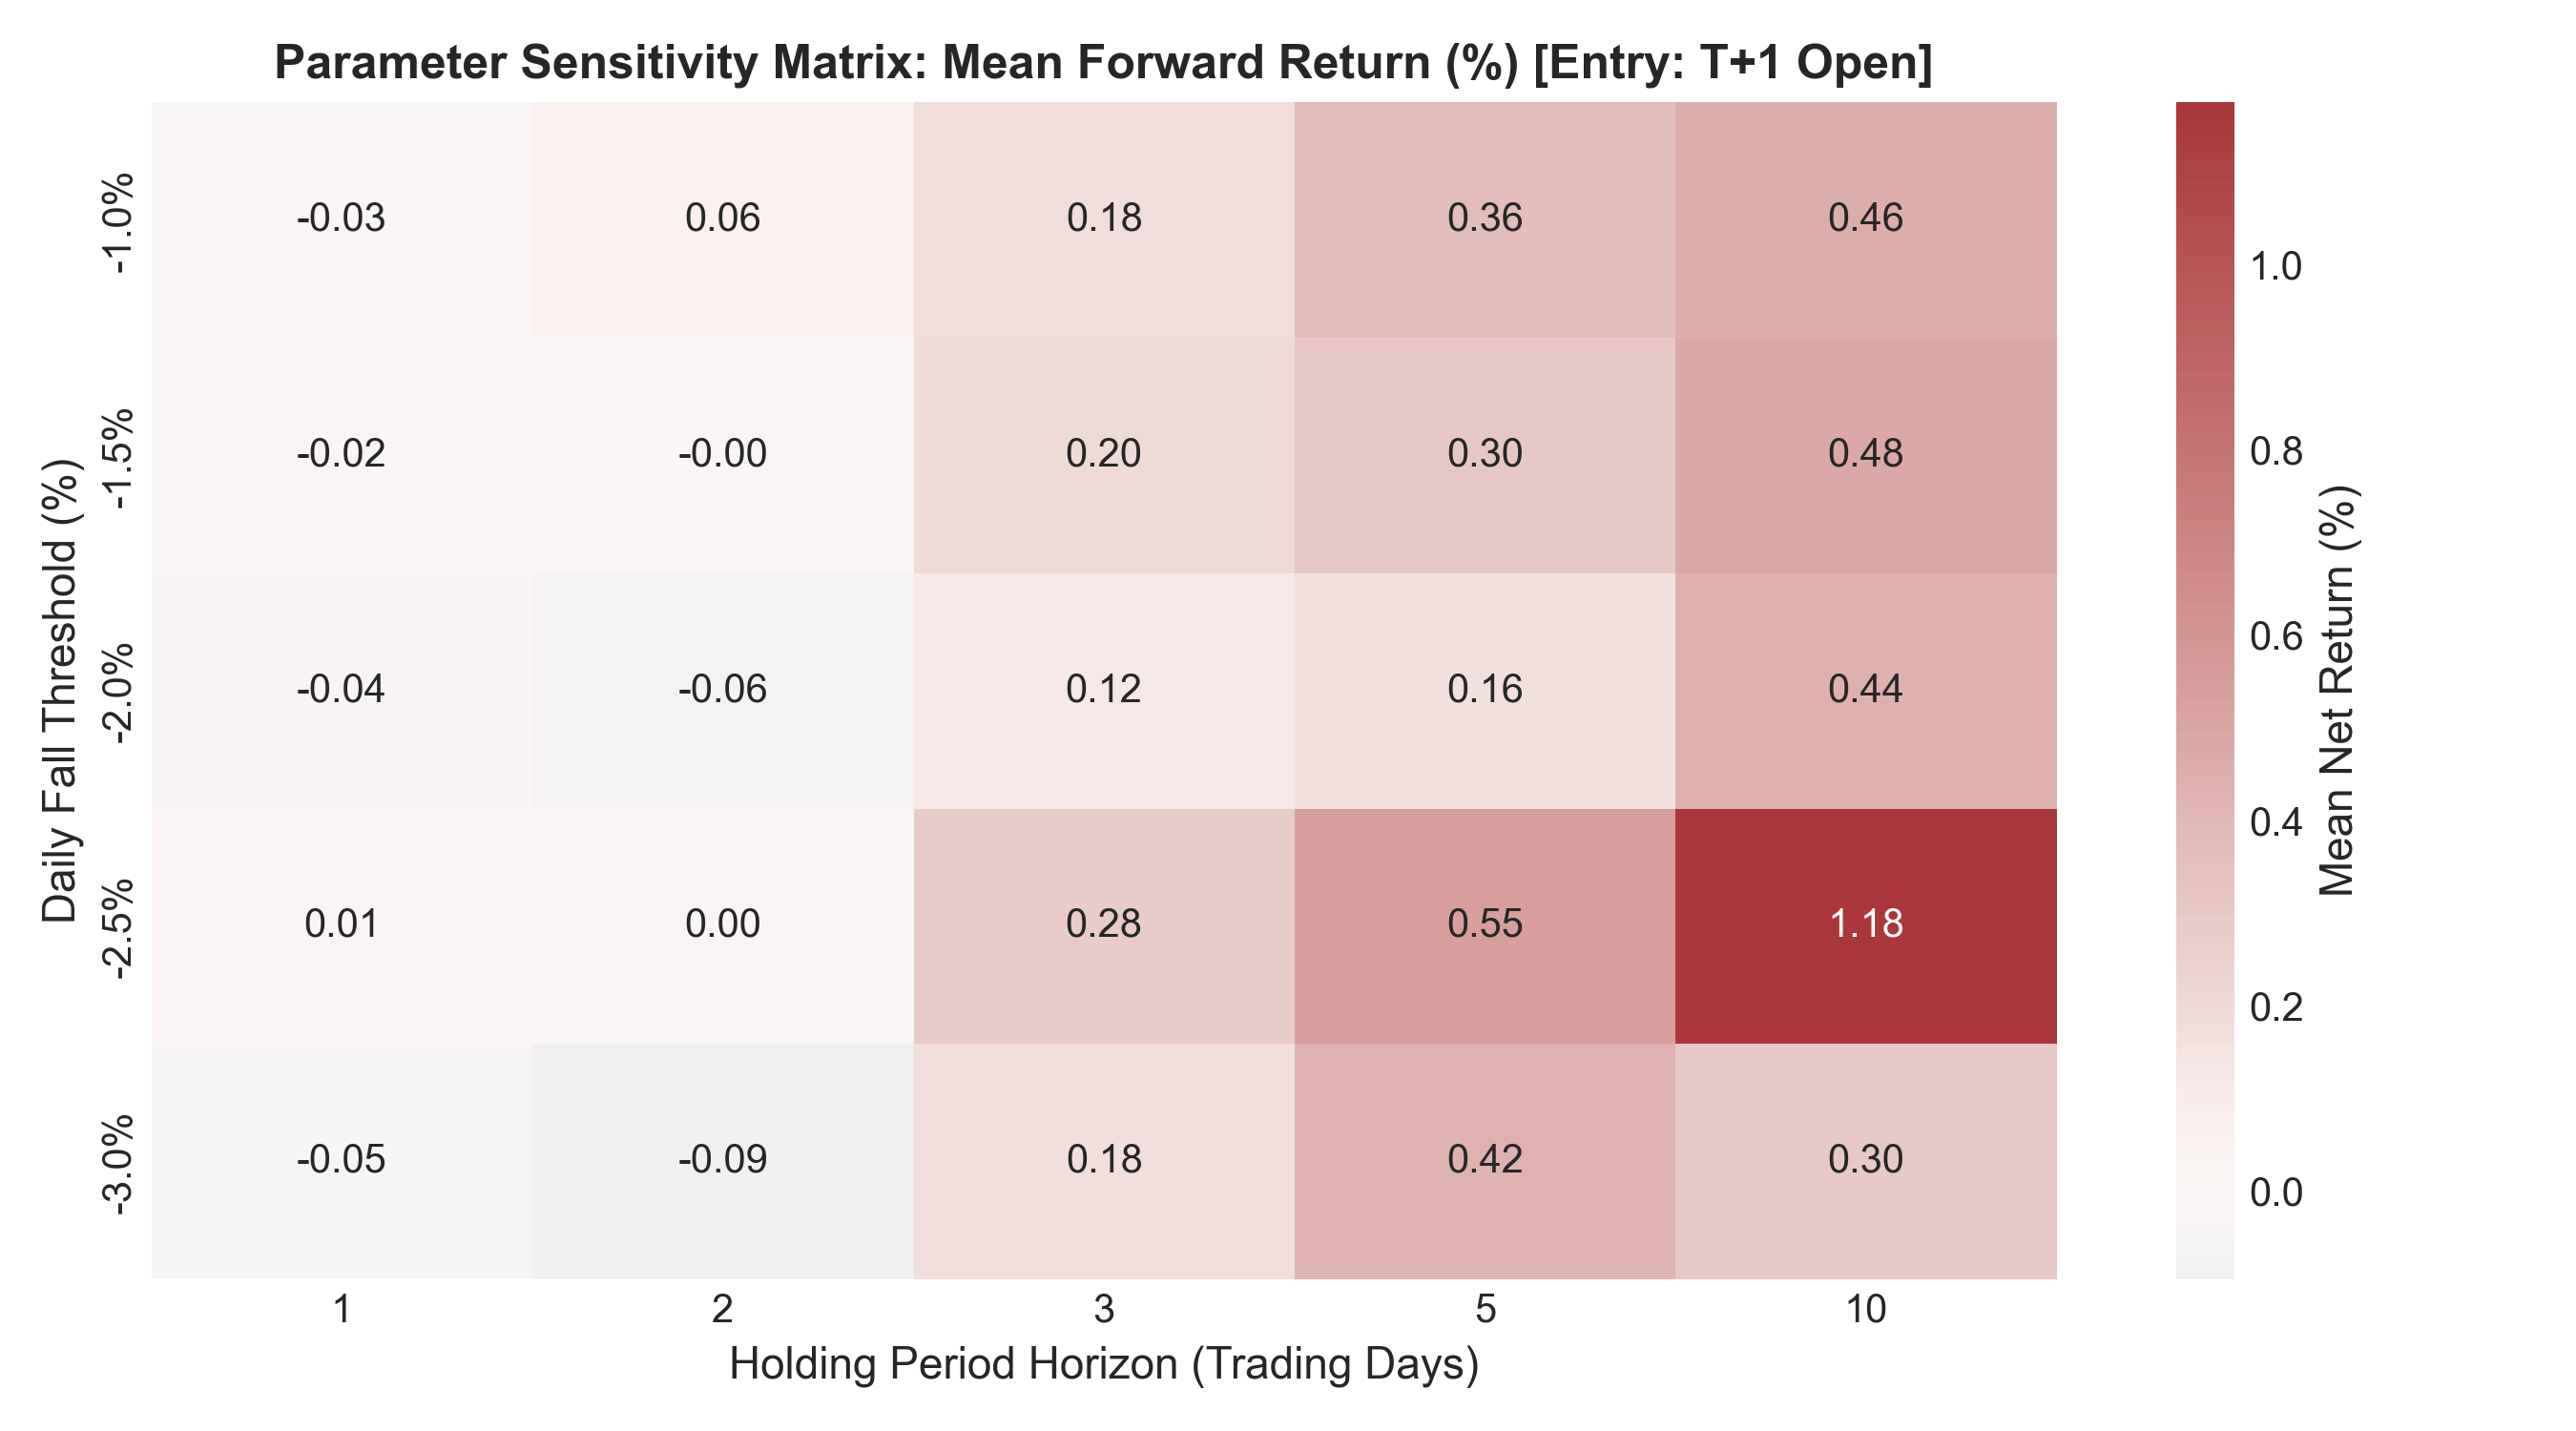

In [7]:
thresholds = [-0.010, -0.015, -0.020, -0.025, -0.030]
horizons = [1, 2, 3, 5, 10]
sensitivity_rows = []

for t in thresholds:
    ev_sub = engine.extract_event_dataset(threshold=t, filter_overlapping=False)
    for h in horizons:
        ret_series = ev_sub[f'fwd_ret_open_{h}d'].dropna()
        sensitivity_rows.append({
            'threshold_pct': f"{t*100:.1f}%",
            'holding_days': h,
            'events_n': len(ret_series),
            'mean_return_pct': ret_series.mean() * 100.0,
            'win_rate_pct': (ret_series > 0).mean() * 100.0
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
plot_sensitivity_heatmap(sensitivity_df, save_path='../reports/figures/parameter_sensitivity_heatmap.png')
Image('../reports/figures/parameter_sensitivity_heatmap.png')

## 6. Out-of-Sample Validation: 2007–2019 vs 2020–2026
We split data chronologically to test whether the apparent edge is robust or a artifact of post-COVID liquidity.

[Visualizer] Saved regime comparison plot to '../reports/figures/regime_comparison.png'


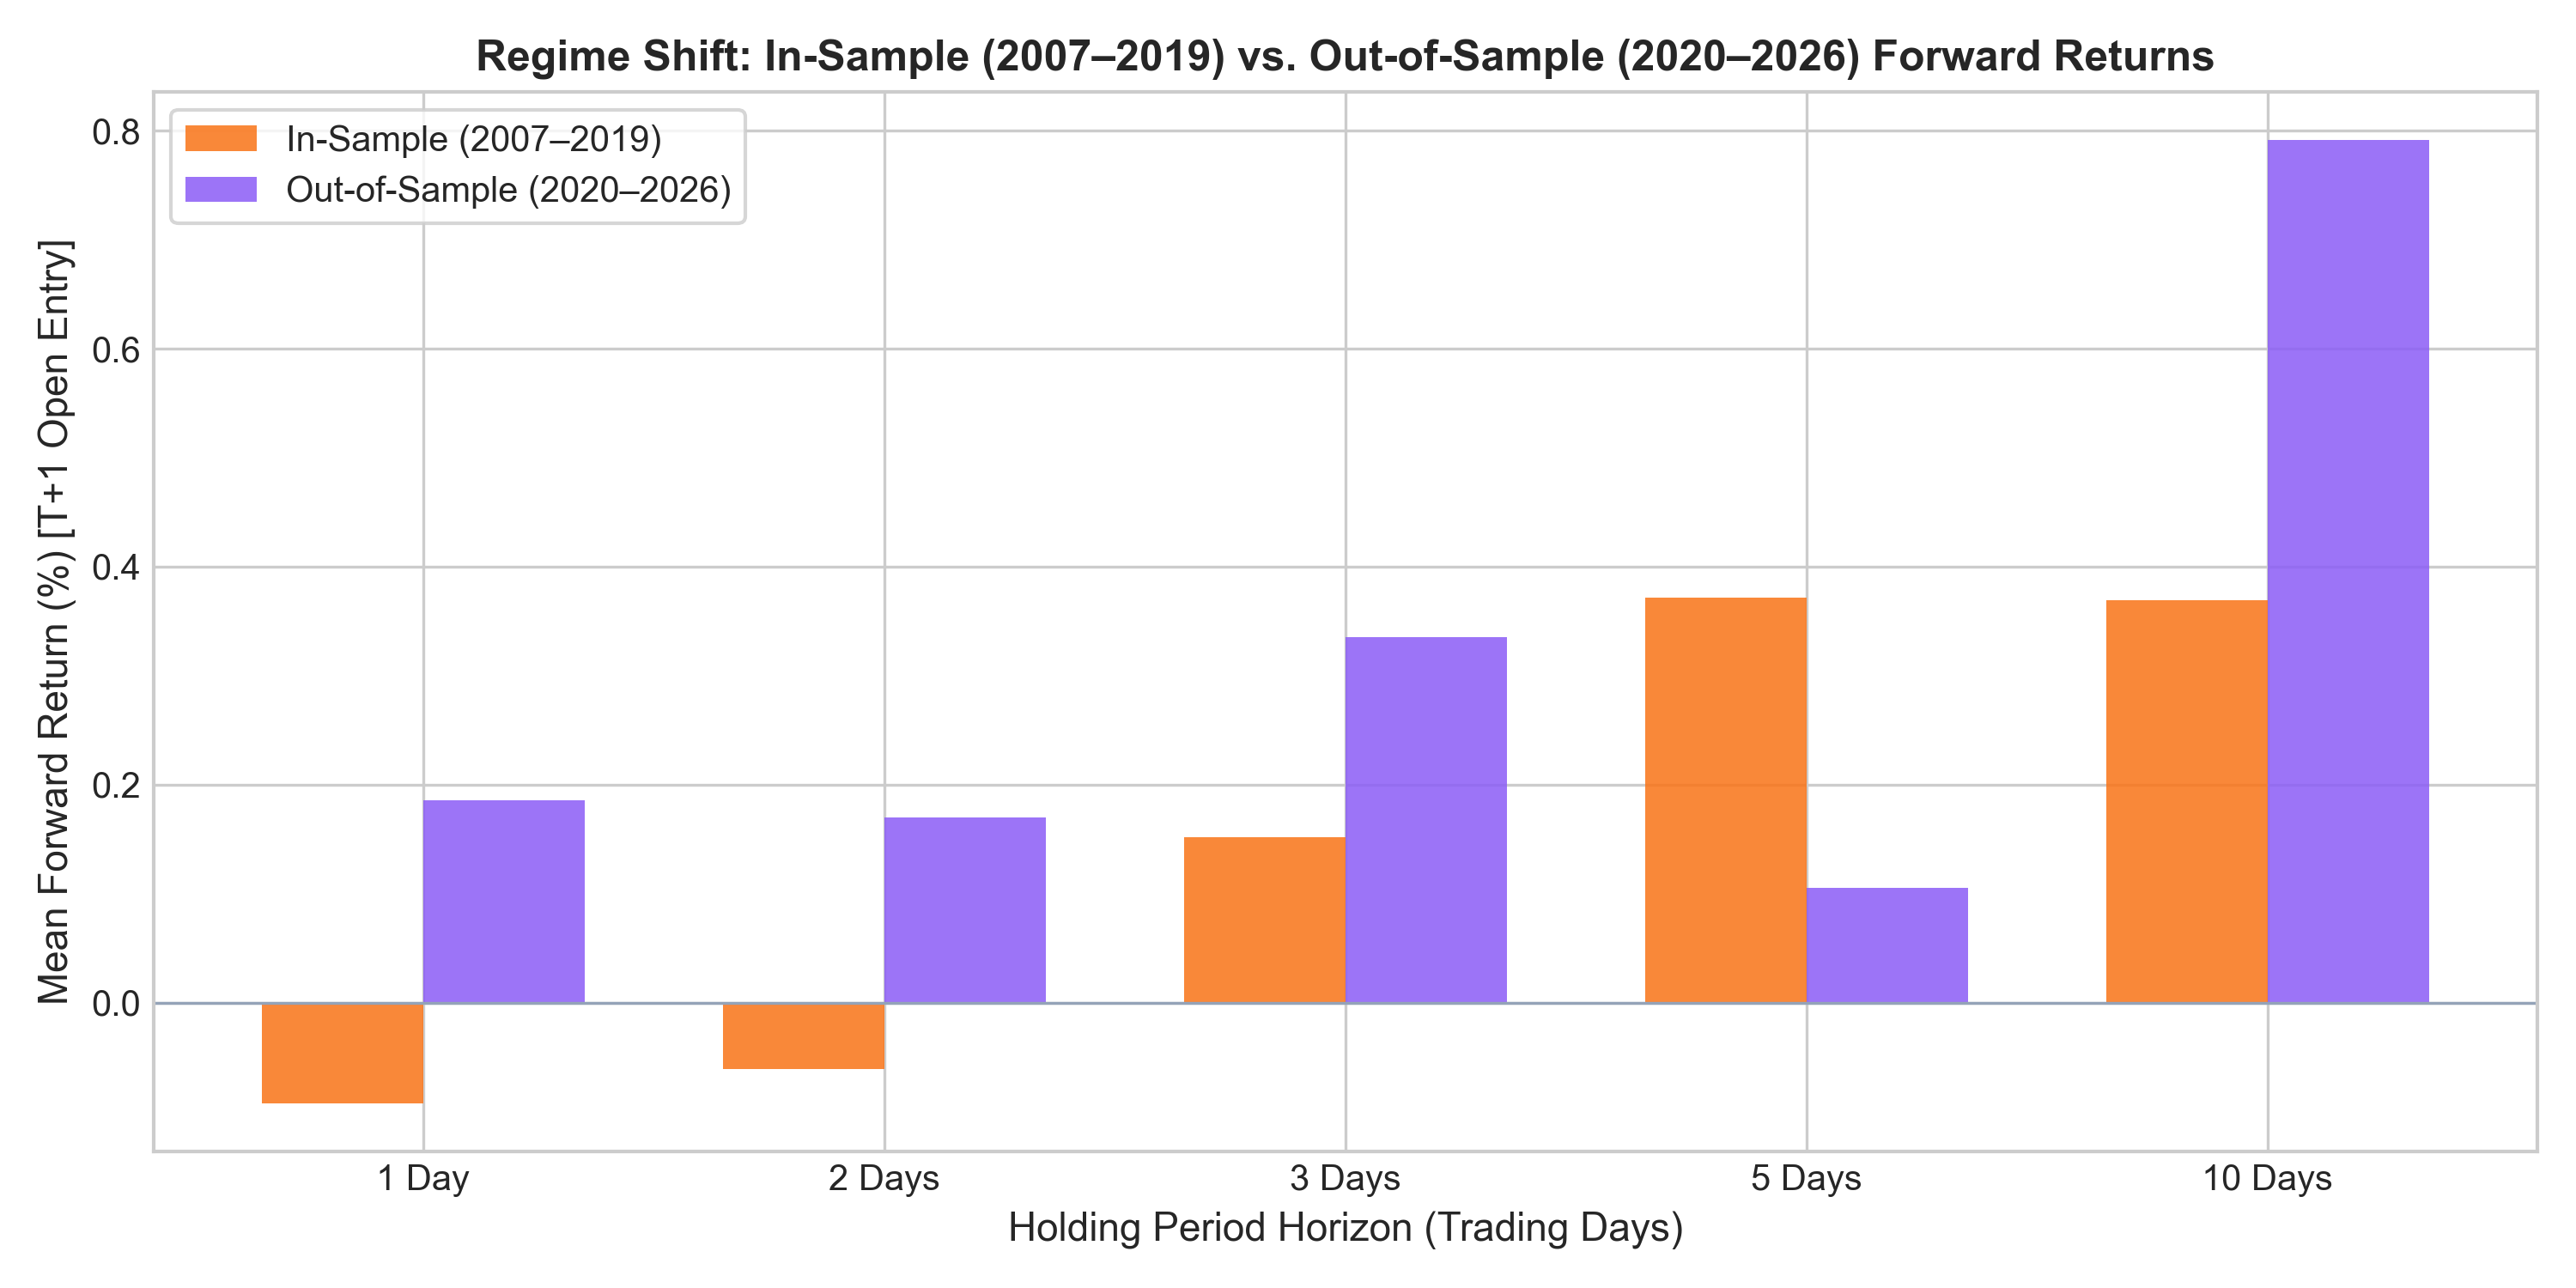

In [8]:
split_date = '2020-01-01'
df_is = df[df['date'] < split_date].copy()
df_oos = df[df['date'] >= split_date].copy()

engine_is = EventEngine(df_is)
engine_oos = EventEngine(df_oos)
events_is = engine_is.extract_event_dataset(threshold=-0.015)
events_oos = engine_oos.extract_event_dataset(threshold=-0.015)

regime_rows = []
for h in [1, 2, 3, 5, 10]:
    ret_is = events_is[f'fwd_ret_open_{h}d'].dropna()
    ret_oos = events_oos[f'fwd_ret_open_{h}d'].dropna()
    regime_rows.append({
        'regime': 'In-Sample (2007-2019)',
        'holding_days': h,
        'mean_return_pct': ret_is.mean() * 100.0,
        'win_rate_pct': (ret_is > 0).mean() * 100.0
    })
    regime_rows.append({
        'regime': 'Out-of-Sample (2020-2026)',
        'holding_days': h,
        'mean_return_pct': ret_oos.mean() * 100.0,
        'win_rate_pct': (ret_oos > 0).mean() * 100.0
    })

regime_df = pd.DataFrame(regime_rows)
plot_regime_comparison(regime_df, save_path='../reports/figures/regime_comparison.png')
Image('../reports/figures/regime_comparison.png')

## 7. Event-Driven Backtest Simulation (with Transaction Costs)
We simulate live trading with 10 bps round-trip costs and slippage, comparing realistic $T+1$ Open execution against Buy & Hold.

[Visualizer] Saved equity and drawdown plot to '../reports/figures/equity_curve_and_drawdowns.png'


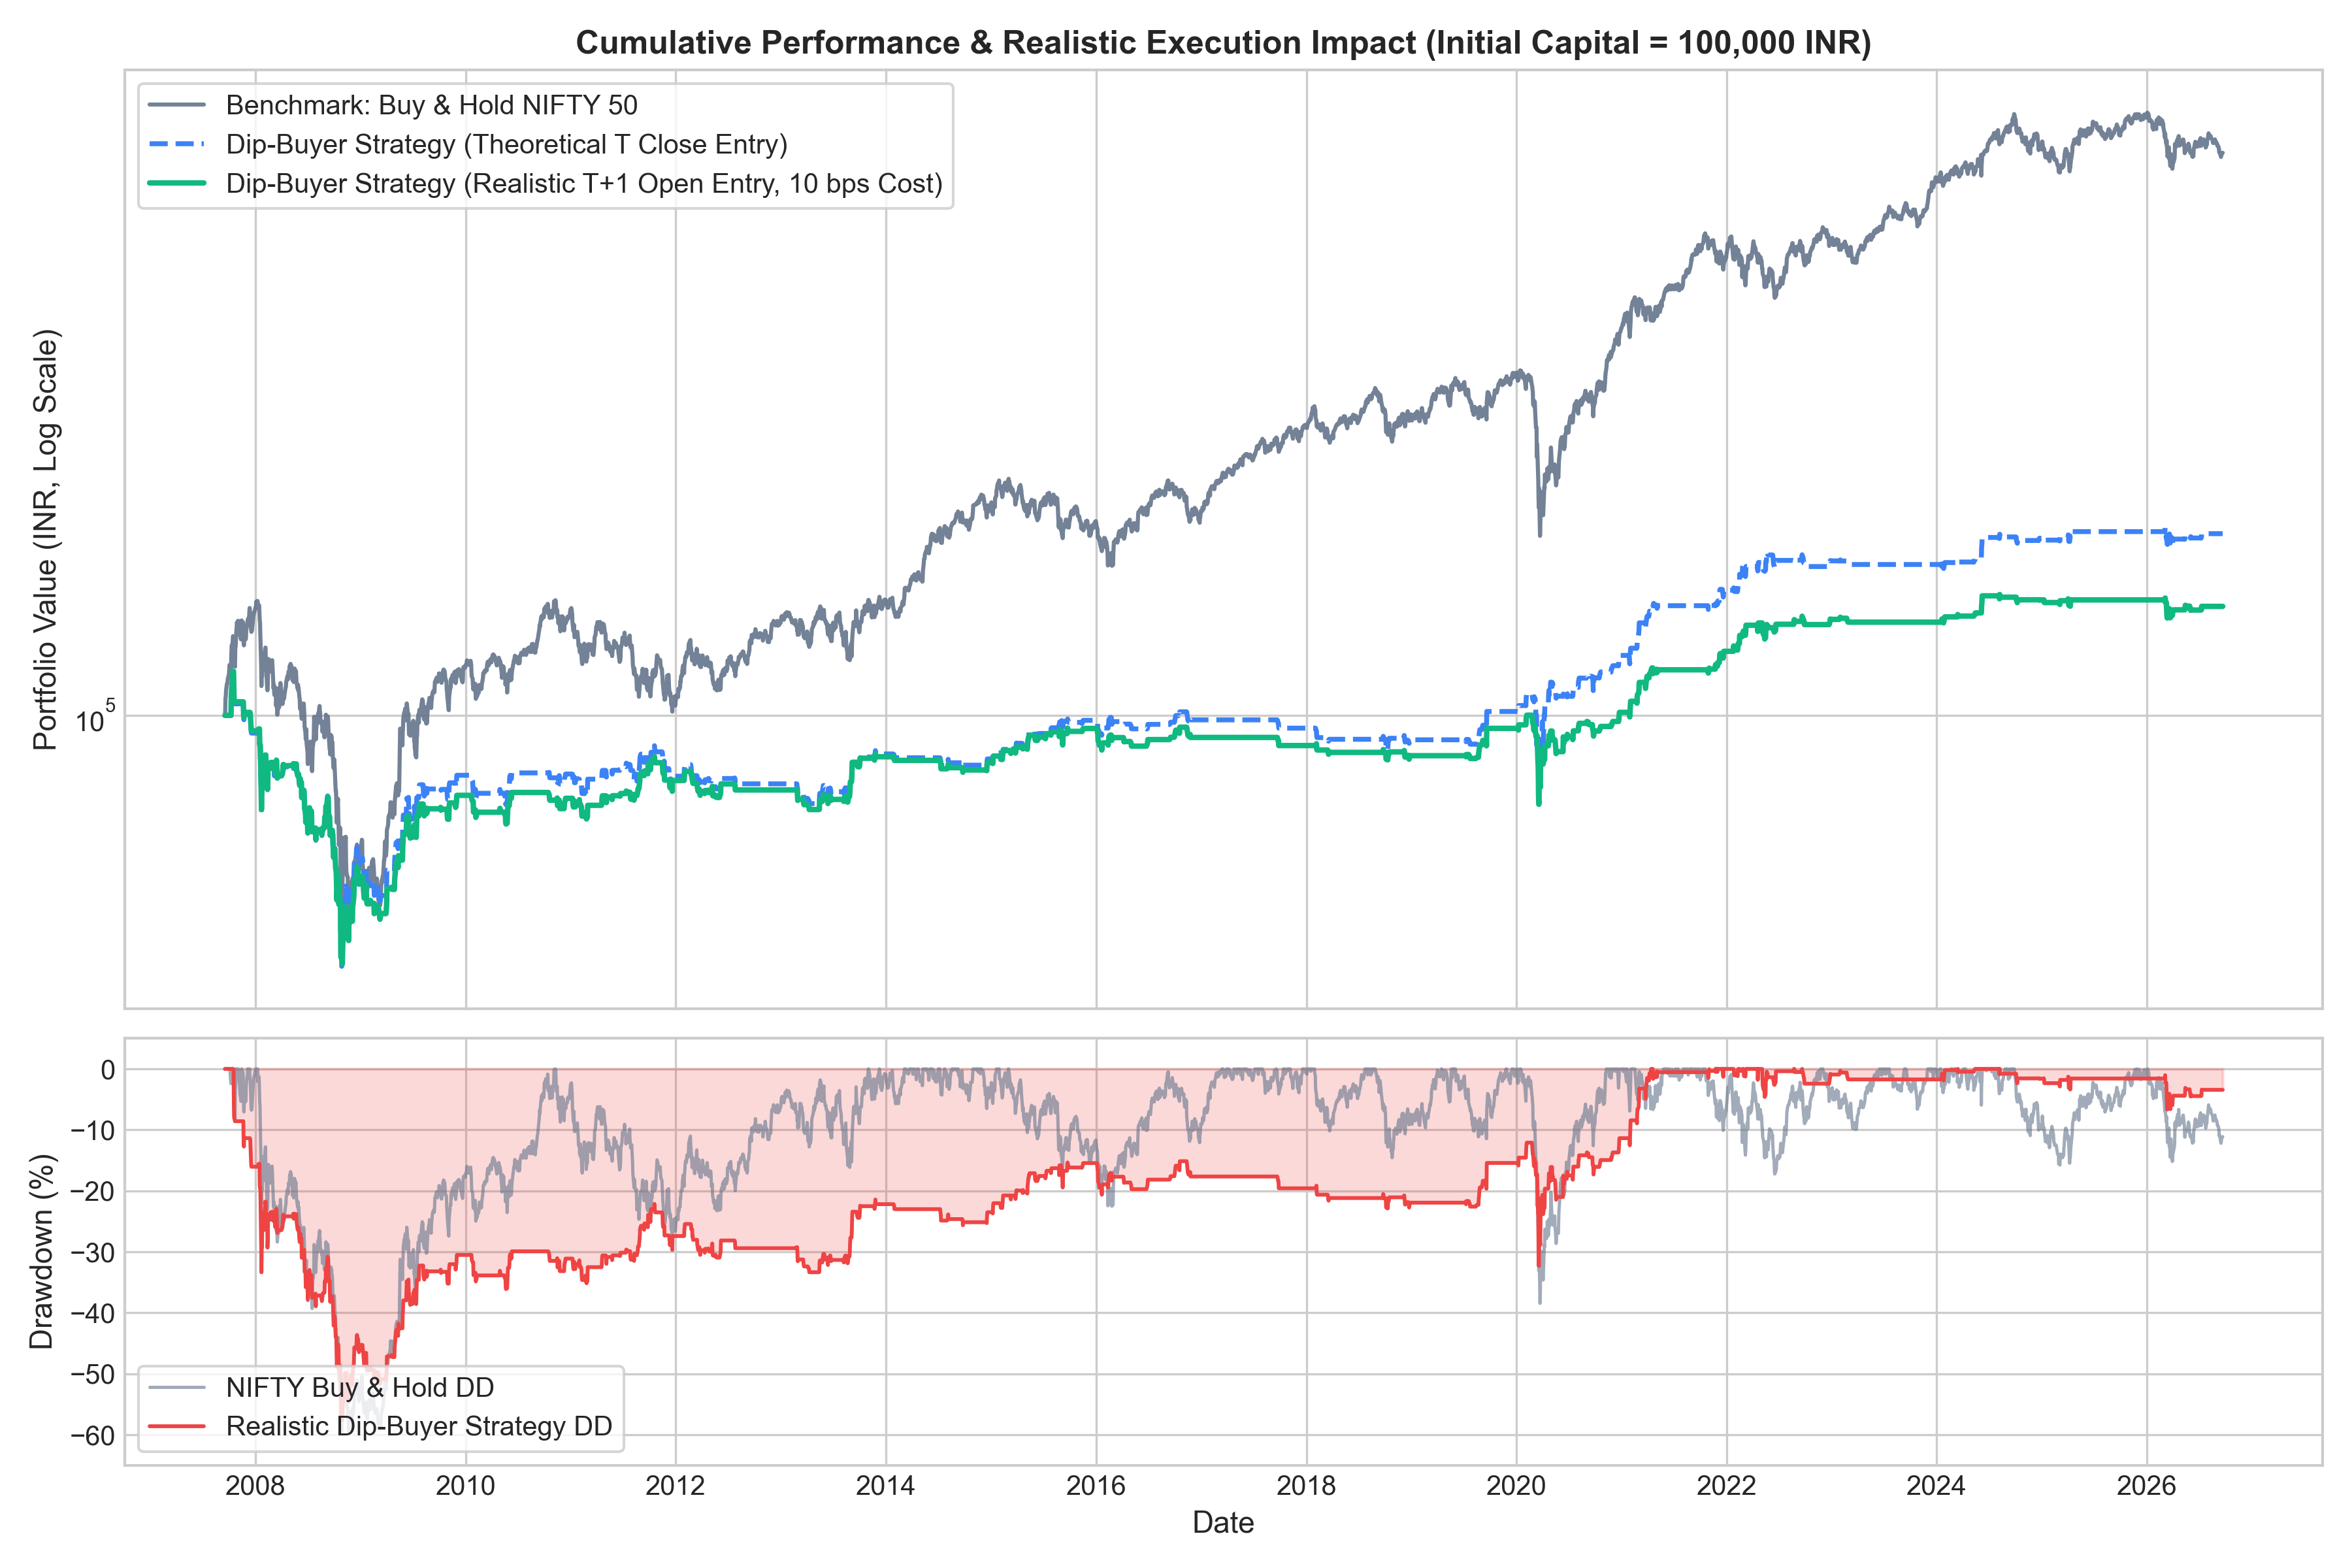

In [9]:
mask_primary = engine.detect_events(threshold=-0.015)
bt = EventBacktester(df, initial_capital=100000.0, transaction_cost_bps=10.0)

res_bt_open = bt.run_backtest(mask_primary, holding_days=3, entry_mode='open')
res_bt_close = bt.run_backtest(mask_primary, holding_days=3, entry_mode='close')

plot_equity_and_drawdowns(res_bt_open['daily_equity'], res_bt_close['daily_equity'], save_path='../reports/figures/equity_curve_and_drawdowns.png')
Image('../reports/figures/equity_curve_and_drawdowns.png')

## 8. Summary of Findings & Research Conclusion
1. **Falsification of Naive Mean-Reversion:** Post-event returns are statistically indistinguishable from the unconditional upward drift of NIFTY ($p > 0.50$ across all horizons).
2. **Execution Reality:** Moving from theoretical $T$ Close to realistic $T+1$ Open turns 1-day and 2-day returns negative due to opening gap-downs.
3. **Regime Vulnerability:** The strategy incurs catastrophic drawdowns (-57.6%) during sustained selloffs (2008 GFC, March 2020) by attempting to catch falling knives.
4. **Verdict:** We reject the naive unconditioned hypothesis. Dip-buying is viable only when conditioned on macro liquidity and trend filters.